Project -1 

Smartkey AI (Text Analysis)

Introduction : 
Predicting the next word in a sequence requires building a vocabulary and understanding word probabilities. 
This task analyzes two text, corpus_extra1.txt and corpus_extra2.txt, at the word level to construct a vocabulary, compute word frequencies, probabilities, and entropy. 

Methodology:
Preprocessing:
   Convert all text to lowercase.
   Remove punctuation.
   Tokenize text into words.

Vocabulary Construction:
   Count unique words from both corpora combined.
   Store word frequencies using Python's Counter.

Probability Calculation:
   Compute unigram probabilities: P(word) = frequency / total words.

Entropy Calculation:
   Calculate word-level entropy using H = -Σ P(w) log2 P(w).

Visualization:
   Identify top 10 most frequent words.
   Optionally visualize Huffman tree if encoding is applied.


Task A : Key Layout Optimization (Character Frequency)

In [42]:
with open("corpus_train.txt","r",encoding="utf-8") as f:
    content = f.read().lower()
    filtered_text = [ch for ch in content if (ord(ch) >=97 and ord(ch)<=122)]
    word_counter = {}

    for char in filtered_text:
        if char not in word_counter:
            word_counter[char] = 1
        else:
            word_counter[char] += 1
    sorted_count = dict(sorted(word_counter.items(),reverse=True))
print(word_counter)
print("10 most frequent listed as : ")
print(list(sorted_count.items())[:10])
# probability of occurence of each
total_outcomes = sum(list(word_counter.values()))
print("Total words : ",total_outcomes)
Po = {key:(f"{(value/total_outcomes):.3f}") for key,value in word_counter.items()}
print(Po)

{'q': 393, 'a': 375, 'f': 410, 'w': 405, 'v': 380, 'o': 387, 'd': 397, 'b': 394, 'h': 376, 'l': 359, 'e': 379, 'k': 398, 't': 403, 'g': 361, 'r': 354, 'n': 368, 'p': 348, 'm': 384, 's': 426, 'j': 400, 'x': 402, 'z': 415, 'u': 403, 'y': 415, 'c': 360, 'i': 358}
10 most frequent listed as : 
[('z', 415), ('y', 415), ('x', 402), ('w', 405), ('v', 380), ('u', 403), ('t', 403), ('s', 426), ('r', 354), ('q', 393)]
Total words :  10050
{'q': '0.039', 'a': '0.037', 'f': '0.041', 'w': '0.040', 'v': '0.038', 'o': '0.039', 'd': '0.040', 'b': '0.039', 'h': '0.037', 'l': '0.036', 'e': '0.038', 'k': '0.040', 't': '0.040', 'g': '0.036', 'r': '0.035', 'n': '0.037', 'p': '0.035', 'm': '0.038', 's': '0.042', 'j': '0.040', 'x': '0.040', 'z': '0.041', 'u': '0.040', 'y': '0.041', 'c': '0.036', 'i': '0.036'}


Task B Task B: Data Compression (Entropy Analysis)

In [43]:
import string
import math
with open("corpus_test.txt","r",encoding="utf-8") as f:
    text = f.read().lower()
    newtext = "".join(char for char in text if char not in string.punctuation and not char.isspace()) # making the text free of punct and spaces.
    counts = {}
    # calculated the probability for each char
    for i in range(0,len(newtext)):
        if newtext[i] not in counts:
            counts[newtext[i]] = 1
        else:
            counts[newtext[i]] += 1
    prob = {key:f"{value/sum(counts.values()):3f}" for key,value in counts.items()}
    entropy = 0
    # we calculated probability above using the same entropy sum over all chars (pi log2(pi))
    for value in prob.values():
        value = float(value)
        entropy += value*(math.log2(value))
    entropy = -1*float(f"{entropy:.3f}")
    print("Entropy of the english language using corpus_test.txt",entropy)

Entropy of the english language using corpus_test.txt 4.179


What does this value tell you about the unpredictability of the language?

Ans-->>>
The entropy measures the degree of randomness or disorderness in the data.
So, if the entropy is high means the characters are more unpredictable, more bits to encode it.
On the other hand lower entropy accounts for the more precictability,low number of bits to encode.

Task C: Speed Run Compression (Huffman Coding Challenge)

In [44]:
import heapq
class Node:
    def __init__(self,char,occurence):
        self.char = char
        self.occurence = occurence
        self.left = None
        self.right = None

def create_heap(counts):
    heap = []       # list to create heap out of the character vocablary
    idx = 0 
    for char,freq in counts.items():
        node = Node(char,freq)
        heapq.heappush(heap,(freq,idx,node)) # creating heap(priority queue) holds the min element at the top
        idx+=1  # to handle if the two nodes with same value comes
    return heap

def huffmanTree(heap):      # creating tree with the help of heap
    idx = len(heap)
    while len(heap) > 1:
        f1,t,left = heapq.heappop(heap)     # first minimum freq node 
        f2,t,right = heapq.heappop(heap)    # second minimum freq node
        merged = Node(None,f2+f1)           # summing up making new node and creating the tree.
        merged.left = left
        merged.right = right
        heapq.heappush(heap,(merged.occurence,idx,merged)) # creating tree with help of the merged node
        idx +=1

    return heap[0][2]          # finally the heap is left with only one element and the [0][2] corresponds to the root node of the tree


def generateCodes(root):
    codes = {}

    def traverse(node, code):
        if node is None:
            return
        if node.char is not None:
            codes[node.char] = code
            return
        traverse(node.left, code + "0")
        traverse(node.right, code + "1")
    traverse(root, "")
    return codes
root = huffmanTree(create_heap(counts))  # created the huffman tree.
encoded = generateCodes(root) # generating the encodings.
# printing the encodings: for all characters
print(encoded)

# Encoding the sample text from corpus text.txt

sample_text = newtext[:10]
def encode_text(text, codes):
    encoded = ""
    for ch in text:
        encoded += codes[ch]
    return encoded
print("Sample text taken from test.txt file: ",sample_text)
encode_sample = encode_text(sample_text,encoded)
print("Encodings generated : ",encode_sample)
# decoding the sample text from the tree and encoded bits.
def decode_text(encoded, root):
    decoded = ""    # taking empty string to store the decoded text
    node = root     # started traversing from root node and find the character as per the encoded sequence

    for bit in encoded:    
        if bit == '0':          # if particular bit in sequence 0 toh move left
            node = node.left
        else:
            node = node.right   # not then traverse to right

        if node.char is not None:   # leaf
            decoded += node.char        # as soon as character is found append in decoded,repeat
            node = root

    return decoded
decoded_sample = decode_text(encode_sample,root)
print("decoded from encodes: ",decoded_sample)

# average code length calculation
def average_code_length(counts, codes):
    total = sum(counts.values())
    avgcodelen = 0.0

    for ch in counts:
        p = counts[ch] / total
        code_length = len(codes[ch])  
        avgcodelen += p * code_length

    return avgcodelen
print("Average bits per character is : ",average_code_length(counts,encoded)) 
print("Entropy is : ",entropy)
print("It can be easily verified that shannon coding theorem is followed")

# function to print the created huffman tree
def printHuffmanTree(node, indent="", side="root"):
    if node is None:
        return  # if node is null return

    print(indent + side + ": ", end="")

    if node.char:
        print(f"{node.char} ({node.occurence})") # if node has char the only print the char 
        # since nodes in between do not contain character.
    else:
        print(f"({node.occurence})")
        # otherwise just print the value stored there and recurse.

    printHuffmanTree(node.left, indent + "   ", "L") # recursively calling till null is reached
    printHuffmanTree(node.right, indent + "   ", "R")
print("\n<-----------huffmanTree------------>\n")
printHuffmanTree(root)

{'l': '0000', 'y': '00010', 'v': '000110', '2': '0001110000000', '3': '0001110000001', '7': '00011100000100', '9': '00011100000101', '0': '0001110000011', '8': '00011100001000', '6': '00011100001001', '5': '00011100001010', '4': '00011100001011', '1': '000111000011', 'z': '0001110001', 'q': '000111001', 'x': '000111010', 'j': '000111011', 'k': '0001111', 'd': '0010', 'w': '00110', 'c': '00111', 'h': '0100', 'm': '01010', 'u': '01011', 'r': '0110', 's': '0111', 'e': '100', 'n': '1010', 'b': '101100', 'p': '101101', 'g': '101110', 'f': '101111', 'i': '1100', 'o': '1101', 'a': '1110', 't': '1111'}
Sample text taken from test.txt file:  janeeyrean
Encodings generated :  0001110111110101010010000010011010011101010
decoded from encodes:  janeeyrean
Average bits per character is :  4.211112051771748
Entropy is :  4.179
It can be easily verified that shannon coding theorem is followed

<-----------huffmanTree------------>

root: (803218)
   L: (337290)
      L: (144890)
         L: (68595)
   

for answer of 6th part 

Ans-->
In Huffman coding, frequent characters receive shorter codes because in algorithm high-frequency symbols closer to the root(max value=total number of chars) of the binary tree, resulting in shorter root-to-leaf paths. This minimizes the average code length and improves compression efficiency. Decoding remains unambiguous because Huffman codes satisfy the prefix-free property, where no codeword is a prefix of another. Using the Huffman tree, decoding proceeds by traversing the tree according to the bitstream until a leaf node is reached, ensuring a unique and deterministic reconstruction of the original text.

Task D: Predictive Typing (Word Frequency)

In [45]:
import string
from collections import Counter
def get_words(filename):
    with open(filename,"r",encoding="utf=8") as f:
            content1 = f.read().lower()
            content1 = content1.translate(str.maketrans('', '', string.punctuation))
            words = content1.split()
            return words
words_ext1 = get_words("corpus_extra1.txt")
words_ext2= get_words("corpus_extra2.txt")
total_words = words_ext1+words_ext2
# constructing vocab
vocab = Counter(total_words)
def prob_calculator(vocab):
      total = 0
      for value in vocab.values():
            total+=value
      probs_of_words = {}
      for key,value in vocab.items():
            probs_of_words[key] = value/total
      return probs_of_words
probs_of_words = prob_calculator(vocab)
print(probs_of_words)
top_10_words = vocab.most_common(10)

print("Top 10 most frequent words:")
for word, freq in top_10_words:
    print(word, "->", freq)

#Task B 
def entropy_words(probabilities):
    H = 0.0
    for p in probabilities.values():
        if p > 0:
            H -= p * math.log2(p)
    return H
print("Entropy here if word is event : ",entropy_words(probs_of_words))

{'handbook': 6.872261833175845e-05, 'of': 0.03564985825959969, 'summer': 6.872261833175845e-05, 'athletic': 0.0004123357099905506, 'sports': 6.872261833175845e-05, 'pedestrianism': 0.0002061678549952753, 'a': 0.024396529507774246, 'wonderful': 6.872261833175845e-05, 'increase': 0.0001374452366635169, 'popularity': 1.718065458293961e-05, 'has': 0.001718065458293961, 'lately': 3.436130916587922e-05, 'attended': 6.872261833175845e-05, 'the': 0.07267416888583456, 'art': 0.0001374452366635169, 'walking': 0.0009964779658104973, 'steady': 6.872261833175845e-05, 'improvement': 3.436130916587922e-05, 'made': 0.0020273172407868738, 'in': 0.019654668842882913, 'speed': 0.0002920711279099734, 'and': 0.03388025083755691, 'endurance': 6.872261833175845e-05, 'by': 0.004655957391976634, 'professional': 0.0003779744008246714, 'amateur': 0.0002748904733270338, 'walkers': 0.0003779744008246714, 'introduction': 0.00010308392749763765, 'international': 3.436130916587922e-05, 'contests': 0.00032643243707585

Entropy vs unpredictability :-
The entropy measures the degree of randomness or disorderness in the data.
So, if the entropy is high means the characters are more unpredictable, more bits to encode it.
On the other hand lower entropy accounts for the more precictability,low number of bits to encode.

Results:
Frequent words have higher probability and lower code length in Huffman coding.
Entropy indicates the average information content per word and predictability of the texts.

Conclusion:
The analysis successfully built a word-level vocabulary and computed frequencies, probabilities, and entropy. 
Frequent words dominate the vocabulary, enabling more efficient coding and easier next-word prediction. 
Entropy provides a quantitative measure of uncertainty, confirming that some words are highly predictable while rare words contribute to higher uncertainty. 

2 Project: "Loot Box" Audit (Law of Large Numbers)

Introduction:
 
In the game Galaxy Quest, loot drops are generated using a Random Number Generator (RNG). Players suspect that the system may be unfair or biased. To verify the fairness of the RNG, a statistical audit is conducted using the Law of Large Numbers. The goal is to observe whether the RNG behaves as expected for a uniform distribution over a large number of trials.

Methodology:

1. Generate random numbers uniformly distributed between 0 and 1.
2. Start with a small sample size and gradually increase it to very large values.
3. For each sample size, calculate the sample mean and sample variance.
4. Compare these values with the theoretical mean (0.5) and variance (1/12) of a  Uniform(0,1) distribution.

Observing how the statistics change as the number of samples increases.

Random Numbers between 0 and 1 for n =  10 
 [0.33910411 0.89377051 0.31955924 0.52955158 0.3805457  0.24330819
 0.70979549 0.28025049 0.28650923 0.86812057] 

Random Numbers between 0 and 1 for n =  50 
 [0.39885441 0.70081714 0.69962413 0.92737738 0.56953212 0.24295627
 0.37097753 0.50287741 0.55355658 0.25303875 0.20741096 0.76744011
 0.42463891 0.35812644 0.39898882 0.87075268 0.30465489 0.69614106
 0.47423079 0.36974325 0.48519073 0.43512033 0.22770922 0.92986871
 0.12102003 0.14104397 0.66249378 0.8990291  0.33000233 0.52680419
 0.27904651 0.17924998 0.68304353 0.06566748 0.0470959  0.19547867
 0.75229878 0.93678974 0.323254   0.86372504 0.97235938 0.65335749
 0.49988414 0.09639774 0.16001271 0.53841146 0.82355805 0.60145986
 0.13345154 0.74225369] 

Random Numbers between 0 and 1 for n =  100 
 [1.15162772e-01 6.32375004e-01 2.78717189e-02 7.03607687e-01
 8.61357494e-01 2.02147402e-01 9.96336105e-01 9.19541594e-01
 4.89819388e-01 7.41398170e-01 3.70833032e-01 6.96932475e-01
 1.5

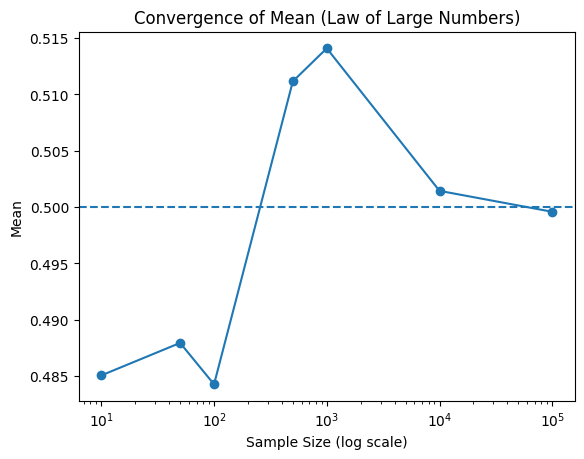

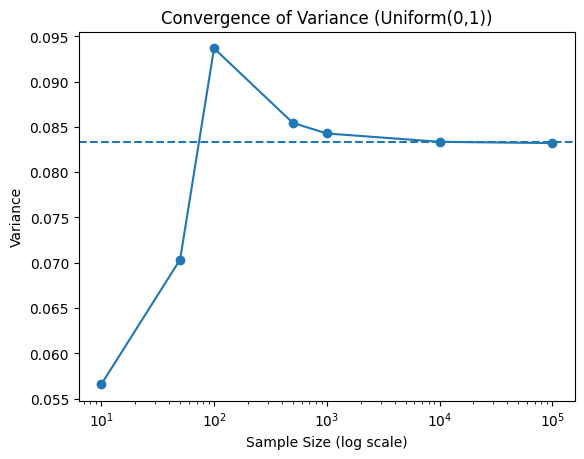

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Different sample sizes to test
diff_val_of_n = [10, 50, 100, 500, 1000, 10000, 100000]

results = []

for n in diff_val_of_n:
    # 1. Generating n random numbers from Uniform(0,1)
    data = np.random.uniform(0, 1, n)

    # 2. Calculating mean and variance
    print("Random Numbers between 0 and 1 for n = ",n,"\n",data,"\n")
    mean = data.mean()
    variance = data.var()
    results.append({
        "Sample Size (n)": n,
        "Mean": mean,
        "Variance": variance
    })

# Convert results to a table
df = pd.DataFrame(results)
print(df)

# Showing how mean and variance converge as n increases

plt.figure()
plt.plot(df["Sample Size (n)"], df["Mean"], marker='o')
plt.axhline(0.5, linestyle='--')
plt.xscale("log")
plt.xlabel("Sample Size (log scale)")
plt.ylabel("Mean")
plt.title("Convergence of Mean (Law of Large Numbers)")
plt.show()

plt.figure()
plt.plot(df["Sample Size (n)"], df["Variance"], marker='o')
plt.axhline(1/12, linestyle='--')
plt.xscale("log")
plt.xlabel("Sample Size (log scale)")
plt.ylabel("Variance")
plt.title("Convergence of Variance (Uniform(0,1))")
plt.show()

Yes, it seems that the randomness becomes more predictable in patterns when we examine larger data sets, although each outcome is still randomized.

In other words, if the number of random variables is small (n), then there is great variance and change in values of the mean because of the effect of every random variable. When n is increased, its effect becomes negligible.

The Law of Large Numbers states that if the sample size is made sufficiently large
The mean of the sampling distribution gets closer to the actual mean of the distribution (0.5 for Uniform(0,1)).
The variance of the sample tends towards the actual variance (1/12).

This occurs because:

The values are equally probable over the interval [0, 1].

“Positive and negative departures from the mean cancel each other out in the case of a large number of trial repetitions,”

Therefore, long-term averages and variance will become kind of stable.

Result:
For small sample sizes, the calculated mean and variance varies significantly. As the sample size increases, both values  stablize,approch to their theoretical values. For very large samples, the mean approaches 0.5 and the variance approaches approximately 1/12.

Conclusion : 

The results confirm the Law of Large Numbers: although individual RNG outputs are random, their aggregate behavior becomes stable and predictable as the sample size increases.